
## Классификация изображений из датасета [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html)


## Задание:

Реализовать алгоримтм позволяющий классифицировать изображения из датасета CIFAR-10 и оценить качество его работы.

Требования:

1. Можете придумать свой алгоритм, загрузить готовую модель или использовать собственную архитектуру.

2. Не используйте предобученные модели.

3. Выберите способ оценки качества предсказаний модели. Обоснуйте его.

4. Проведите обучение. Продемонстрируйте умение использовать специализированные инструменты.

5. Оцените полученный результат.

*Не используйте инструменты принцип работы которых вам непонятен.

### Данные

In [ ]:
# Сделаем все импорты в одном месте, так удобнее

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.optim as optim
from sklearn.metrics import f1_score
from torchvision import models, datasets

In [ ]:
# Есть такой объект. Что он делает:
# 1. ToTensor() - изначально у нас лежат объекты pillow, а нам для обучения нужны тензоры, в них и переводим.
# 2. Normalize() - Нормализация со средним 0,5 и дисперсией 0,5

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
# Сделаем датасет с оригинальными изображениями, чтобы если что их смотреть (origin_dataset)
# А также train/test с применением transform

origin_dataset = datasets.CIFAR10("content", train=True, download=True)
train_dataset = datasets.CIFAR10("content", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10("content", train=False, download=True, transform=transform)

100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s]


In [ ]:
# Посмотрим что происходит внутри датасета

def print_tensor_as_img(img_tensor):
    img_np = np.array(img_tensor)
    plt.imshow(img_np)
    plt.show()

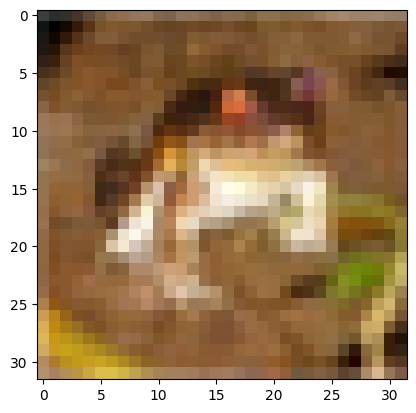

In [ ]:
print_tensor_as_img(origin_dataset[0][0])

In [ ]:
train_dataset[0][0].shape

torch.Size([3, 32, 32])

In [ ]:
cifar_classes = []
for d in origin_dataset:
    cifar_classes.append(d[1])

cifar_classes = np.array(cifar_classes)

In [ ]:
# Вот все наши классы, из 10

np.unique(cifar_classes)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
# Сделаме базовые объекты DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

### Модель

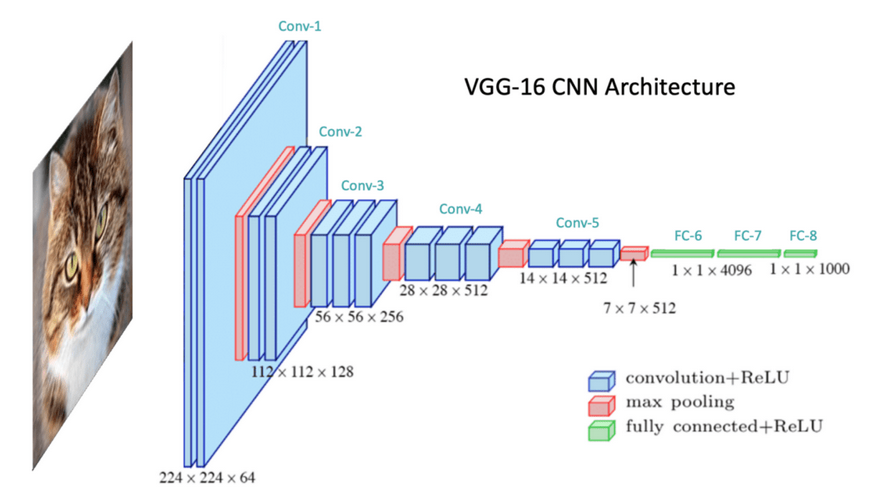

In [ ]:
# Я хочу сделать что-то похожее на картинку сверху, только в меньших масштабах

class VGGBase(nn.Module):
    def __init__(self):
        super(VGGBase, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, padding=2), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=5, padding=2), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(64*4*4, 128), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return x

### Обучение

In [ ]:
# Желательно обучать на cuda, т.к обучение идет очень долго

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
# Функция потерь - кросс энтропия (оценивает вероятность предсказания к классу), + Adam (понижает lr при обучении)

model = VGGBase().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Обучение я скопировал из прошлого ноутбука, где я предсказывал букву на изображении

epochs = 20
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_dataloader)
    print(f"Epoch {epoch}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/20, Loss: 1.7607
Epoch 2/20, Loss: 1.3814
Epoch 3/20, Loss: 1.1989
Epoch 4/20, Loss: 1.0672
Epoch 5/20, Loss: 0.9660
Epoch 6/20, Loss: 0.9011
Epoch 7/20, Loss: 0.8463
Epoch 8/20, Loss: 0.7996
Epoch 9/20, Loss: 0.7621
Epoch 10/20, Loss: 0.7250
Epoch 11/20, Loss: 0.6981
Epoch 12/20, Loss: 0.6723
Epoch 13/20, Loss: 0.6537
Epoch 14/20, Loss: 0.6222
Epoch 15/20, Loss: 0.6077
Epoch 16/20, Loss: 0.5885
Epoch 17/20, Loss: 0.5747
Epoch 18/20, Loss: 0.5619
Epoch 19/20, Loss: 0.5463
Epoch 20/20, Loss: 0.5322


In [ ]:
torch.save(model.state_dict(), 'vgg16_cifar_klyshnikov.pth')

### Оценка результата

In [ ]:
# Сделаем 2 тензора из истинных значений и предсказаний

test_gt = torch.tensor([]).to(device)
test_pred = torch.tensor([]).to(device)

with torch.no_grad():
    for data in test_dataloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_gt = torch.cat([test_gt, labels])
        test_pred = torch.cat([test_pred, predicted])

In [ ]:
# На основе этого посмотрим accuracy и взвешенный f1

print(f'Accuracy: {(test_gt == test_pred).sum() / test_gt.shape[0]}')
print(f'F1: {f1_score(test_gt.cpu(), test_pred.cpu(), average='weighted')}')

Accuracy: 0.708299994468689
F1: 0.7092426240395866


## Вывод

Около 70% предсказыет правильно

Будьте готовы ответить на любые вопросы по коду, процессу обучения, моделям и метрикам.

Буду готов